In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)


setup_styles()
%load_ext autoreload
%autoreload 2

In [3]:
def get_canonical_and_perturbed_df(
    samples,
    only_keep_canonical_true: bool = False,
    keep_remains_or_becomes_correct: bool = False,
    only_keep_perturbed_true: bool = False,
):
    """returns filtered out samples too"""
    if (
        (only_keep_canonical_true and keep_remains_or_becomes_correct)
        or (only_keep_canonical_true and only_keep_perturbed_true)
        or (keep_remains_or_becomes_correct and only_keep_perturbed_true)
    ):
        raise ValueError(
            f"Please pass these exclusively, only_keep_canonical_true: true for canonical, model_name true, keep_remains_or_becomes_correct: True to include the ones where the perturbed version becomes correct"
        )
    print(f"Processing {len(samples)} examples")
    canonical_samples = samples[samples["is_canonical"]]
    perturbed_samples = samples[~samples["is_canonical"]]
    canonical_values = canonical_samples[["set_id", "model_name", METRIC]].rename(
        columns={METRIC: f"canonical_{METRIC}"}
    )

    perturbed_samples = perturbed_samples.merge(
        canonical_values, on=["set_id", "model_name"], how="left"
    )
    perturbed_samples[f"canonical-perturbed_{METRIC}"] = (
        perturbed_samples[f"canonical_{METRIC}"] - perturbed_samples[METRIC]
    )

    if only_keep_canonical_true:
        print(
            f"Cleaning samples, will be dropping entries (set_id-model pairs) where the canonical is predicted wrong."
        )
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]
        print(
            f"Keeping {len(correct_canonical_pairs)} correct pairs, dropping {len(canonical_samples) - len(correct_canonical_pairs)} entries."
        )

        canonical_samples = canonical_samples[canonical_samples[METRIC] == 1]

        # Step 3: Filter perturbed_samples to keep only rows with correct canonical pairs
        # Method 1: Using merge (RECOMMENDED)
        perturbed_samples = perturbed_samples.merge(
            correct_canonical_pairs,
            on=["set_id", "model_name"],
            how="inner",  # Only keep rows that exist in both
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)

    if keep_remains_or_becomes_correct:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]

        # Combine: pairs that either remain correct OR become correct
        remains_or_becomes_correct = pd.concat(
            [correct_canonical_pairs, correct_perturbed_pairs]
        ).drop_duplicates()

        # Filter both datasets to only include these pairs
        canonical_samples = canonical_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        perturbed_samples = perturbed_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)
        print(f"After filtering:{len(samples)}")
    if only_keep_perturbed_true:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        wrong_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 0][
            ["set_id", "model_name"]
        ]
        # Find cases where canonical wrong AND perturbed correct (recovery cases)
        becomes_correct = pd.merge(
            wrong_canonical_pairs,
            correct_perturbed_pairs,
            how="inner",
            on=["set_id", "model_name"], 
        )
        print(becomes_correct)

        # Filter both datasets to only include recovery cases
        canonical_samples = canonical_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        print(canonical_samples[METRIC].sum())

        perturbed_samples = perturbed_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        samples = pd.concat([canonical_samples, perturbed_samples], ignore_index=True)
        print(f"After filtering: {len(samples)}")

    return samples, canonical_samples, perturbed_samples

## Benchmark Subset

In [403]:
METRIC = "acc_norm"
OUTPUT_DIR_ = Path("./output/prelim-results-v5")
OUTPUT_DIR_ = Path("./output/paper-results-v5")

# keeps set_id, model pairs that are correct for canonical
# suffix = "(Still correct)"
# only_keep_canonical_true = True
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = False

# suffix = "(Remains or Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = True
# only_keep_perturbed_true = False

# suffix = "(Flipped to correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True

# keep all the samples
suffix = "(All)" 
only_keep_canonical_true = False
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False


code_pattern = "*tokenizer_robustness_completion_farsi*"
title_pattern = "Farsi - "
OUTPUT_DIR = OUTPUT_DIR_/"farsi"

# code_pattern = "*tokenizer_robustness_completion_turkish*"
# title_pattern = "Turkish - "
# OUTPUT_DIR = OUTPUT_DIR_/"turkish"

# code_pattern = "*tokenizer_robustness_completion_stem*"
# title_pattern = "STEM - "
# OUTPUT_DIR = OUTPUT_DIR_/"stem"

# code_pattern = "*tokenizer_robustness_completion_math*"
# title_pattern = "MATH - "
# OUTPUT_DIR = OUTPUT_DIR_/"math"

# code_pattern = "*tokenizer_robustness_completion_english*"
# title_pattern = "English - "
# OUTPUT_DIR = OUTPUT_DIR_/"english"

# code_pattern = "*tokenizer_robustness_completion_chinese*"
# title_pattern = "Chinese - "
# OUTPUT_DIR = OUTPUT_DIR_/"chinese"

# code_pattern = "*tokenizer_robustness_completion_italian*"
# title_pattern = "Italian - "
# OUTPUT_DIR = OUTPUT_DIR_/"italian"

# code_pattern = "*"
# title_pattern = "All Datasets"
# OUTPUT_DIR = OUTPUT_DIR_/"all"

SUFFIX = suffix.lower().replace("(","").replace(")","")
OUTPUT_DIR = OUTPUT_DIR/SUFFIX
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
base_dir = Path("../results/paper-v5").resolve().absolute()
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(168,
 [PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_canonical_2025-09-20T16-14-33.757080.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_arabic_keyboard_for_farsi_2025-09-20T16-14-33.757080.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_romanization_2025-09-20T16-14-33.757080.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_number_romanization_2025-09-20T16-14-33.757080.jsonl'),
  PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-ll

In [404]:
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)

task_counts = all_samples.groupby("task")["model_name"].value_counts().groupby(level=0).mean()
valid_tasks = task_counts[task_counts>=5].index
all_samples = all_samples[all_samples["task"].isin(valid_tasks)]
all_samples["is_canonical"] = (
    all_samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
)
## exclude anything that is mistaken
all_samples = all_samples[all_samples["subcategories"] != "Turkish, Numerical formats"]
all_samples = all_samples[all_samples["task"] != "tokenizer_robustness_completion_english_space_additions"]
valid_tasks = all_samples.pivot_table(index=["model_name", "task"], values=METRIC, aggfunc="count")
all_samples = all_samples
## filter based on settings specified above
samples, canonical_df, perturbed_df = get_canonical_and_perturbed_df(
    all_samples,
    only_keep_canonical_true=only_keep_canonical_true,
    keep_remains_or_becomes_correct=keep_remains_or_becomes_correct,
    only_keep_perturbed_true=only_keep_perturbed_true,
)

samples.head()
samples["subcategories"].value_counts()
all_samples["set_id"].value_counts()

168 [PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_canonical_2025-09-20T16-14-33.757080.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_arabic_keyboard_for_farsi_2025-09-20T16-14-33.757080.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_romanization_2025-09-20T16-14-33.757080.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_farsi_number_romanization_2025-09-20T16-14-33.757080.jsonl'), PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/results/paper-v5/r-three__supertoken_models-llama_faceboo

set_id
303.0    294
324.0    280
308.0    280
323.0    280
312.0    280
311.0    280
310.0    280
309.0    280
313.0    280
307.0    280
302.0    280
304.0    280
306.0    280
333.0    252
334.0    252
335.0    252
336.0    252
337.0    252
339.0    252
338.0    252
340.0    252
341.0    252
342.0    252
331.0    252
343.0    252
332.0    252
300.0    252
330.0    252
329.0    252
328.0    252
327.0    252
326.0    252
301.0    252
322.0    252
317.0    252
316.0    252
315.0    252
314.0    252
305.0    252
344.0    252
Name: count, dtype: int64

In [405]:
pv = all_samples.pivot_table(index=["model_name", "is_canonical"], values=METRIC)
pv.to_csv(OUTPUT_DIR/f"model_canonical_{METRIC}.csv")
pv

acc_norm
model_name   is_canonical          
Aya          False         0.540311
             True          0.775000
BLOOM        False         0.544554
             True          0.750000
ByT5         False         0.547383
             True          0.775000
Comma        False         0.548798
             True          0.775000
GPT-2        False         0.568600
             True          0.775000
GPT-4o       False         0.553041
             True          0.750000
Gemma-2      False         0.530410
             True          0.750000
Llama-3.2    False         0.545969
             True          0.750000
Phi-3        False         0.558699
             True          0.825000
Qwen-3       False         0.544554
             True          0.850000
Tekken       False         0.557284
             True          0.850000
TokenMonster False         0.558699
             True          0.700000
XGLM         False         0.568600
             True          0.800000
mBERT        False         0.581330
             True          0.800000

              acc_norm
model_name            
Aya           0.552878
BLOOM         0.555556
ByT5          0.559572
Comma         0.560910
GPT-2         0.579652
GPT-4o        0.563588
Gemma-2       0.542169
Llama-3.2     0.556894
Phi-3         0.572959
Qwen-3        0.560910
Tekken        0.572959
TokenMonster  0.566265
XGLM          0.580991
mBERT         0.593039


/var/folders/d7/6swf_cn561v8n6hw_bgg04lh0000gn/T/ipykernel_37327/2916950188.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=palette)


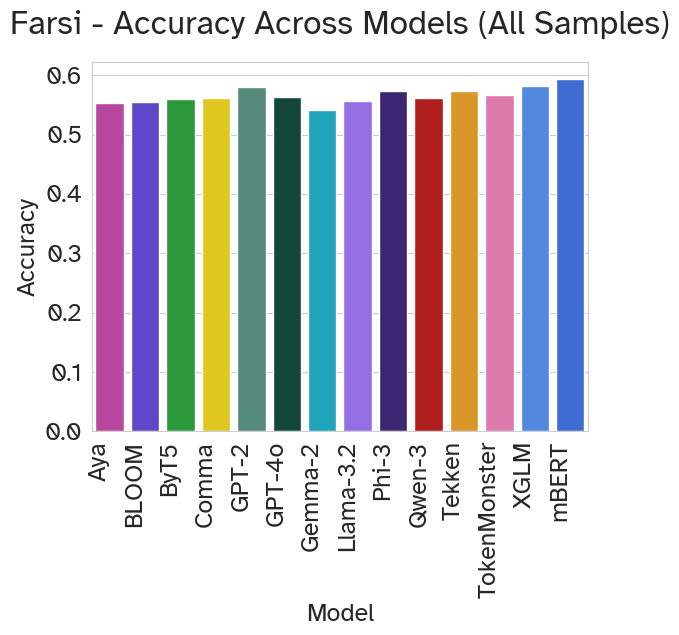

In [406]:
### Here using ALL SAMPLES

XAXIS = "model_name"
palette=MODEL_TO_COLOR
# XAXIS = "vocab_bucket"
# palette=None
accuracies_by_model = all_samples.pivot_table(
    index=XAXIS, values=METRIC, aggfunc="mean"
)
sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=palette)
# sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy")
plt.title(f"{title_pattern}Accuracy Across Models (All Samples)", pad=20)
plt.savefig(OUTPUT_DIR/f"all_samples_{METRIC}.png", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [407]:
samples["vocab_bucket"]

10245     Large
9791      Large
9832      Large
10418     Large
10285     Large
          ...  
7839     Medium
7840     Medium
7841     Medium
7842     Medium
7843     Medium
Name: vocab_bucket, Length: 10458, dtype: object

### Canonical vs. Pertuerbed

                           acc_norm
model_name   is_canonical          
Aya          False         0.540311
             True          0.775000
BLOOM        False         0.544554
             True          0.750000
ByT5         False         0.547383
             True          0.775000
Comma        False         0.548798
             True          0.775000
GPT-2        False         0.568600
             True          0.775000
GPT-4o       False         0.553041
             True          0.750000
Gemma-2      False         0.530410
             True          0.750000
Llama-3.2    False         0.545969
             True          0.750000
Phi-3        False         0.558699
             True          0.825000
Qwen-3       False         0.544554
             True          0.850000
Tekken       False         0.557284
             True          0.850000
TokenMonster False         0.558699
             True          0.700000
XGLM         False         0.568600
             True          0

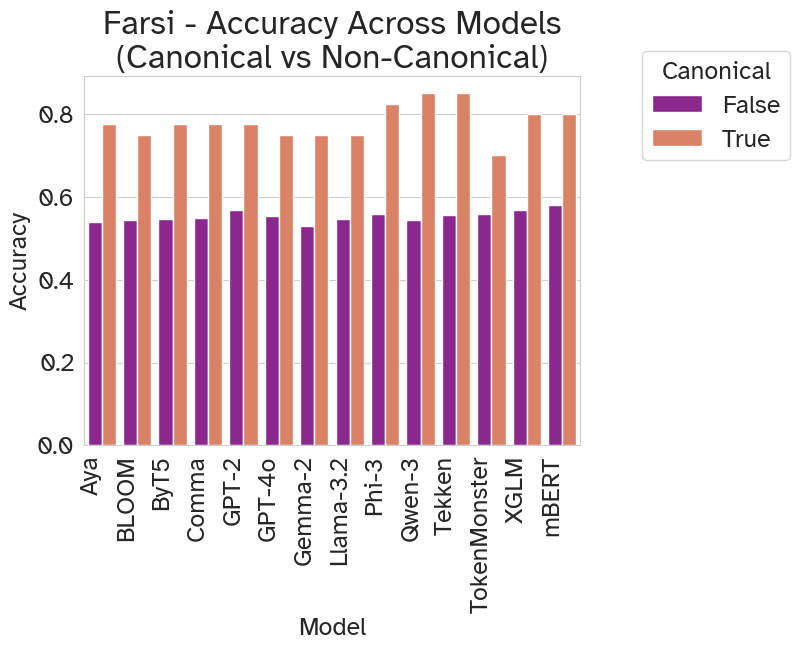

In [408]:
accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "is_canonical"], values=METRIC, aggfunc="mean"
)
# sns.barplot(accuracies_by_model, x="is_canonical", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
# xlabel = "Canonical"
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, hue="is_canonical", palette="plasma")
xlabel = "Model"
plt.xticks(rotation=90, ha="right")
plt.xlabel(xlabel)
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy Across Models\n(Canonical vs Non-Canonical)")
plt.legend(bbox_to_anchor=(1.1, 1.1), title="Canonical")
plt.savefig(OUTPUT_DIR/f"canonical_vs_perturbed_{METRIC}.png", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

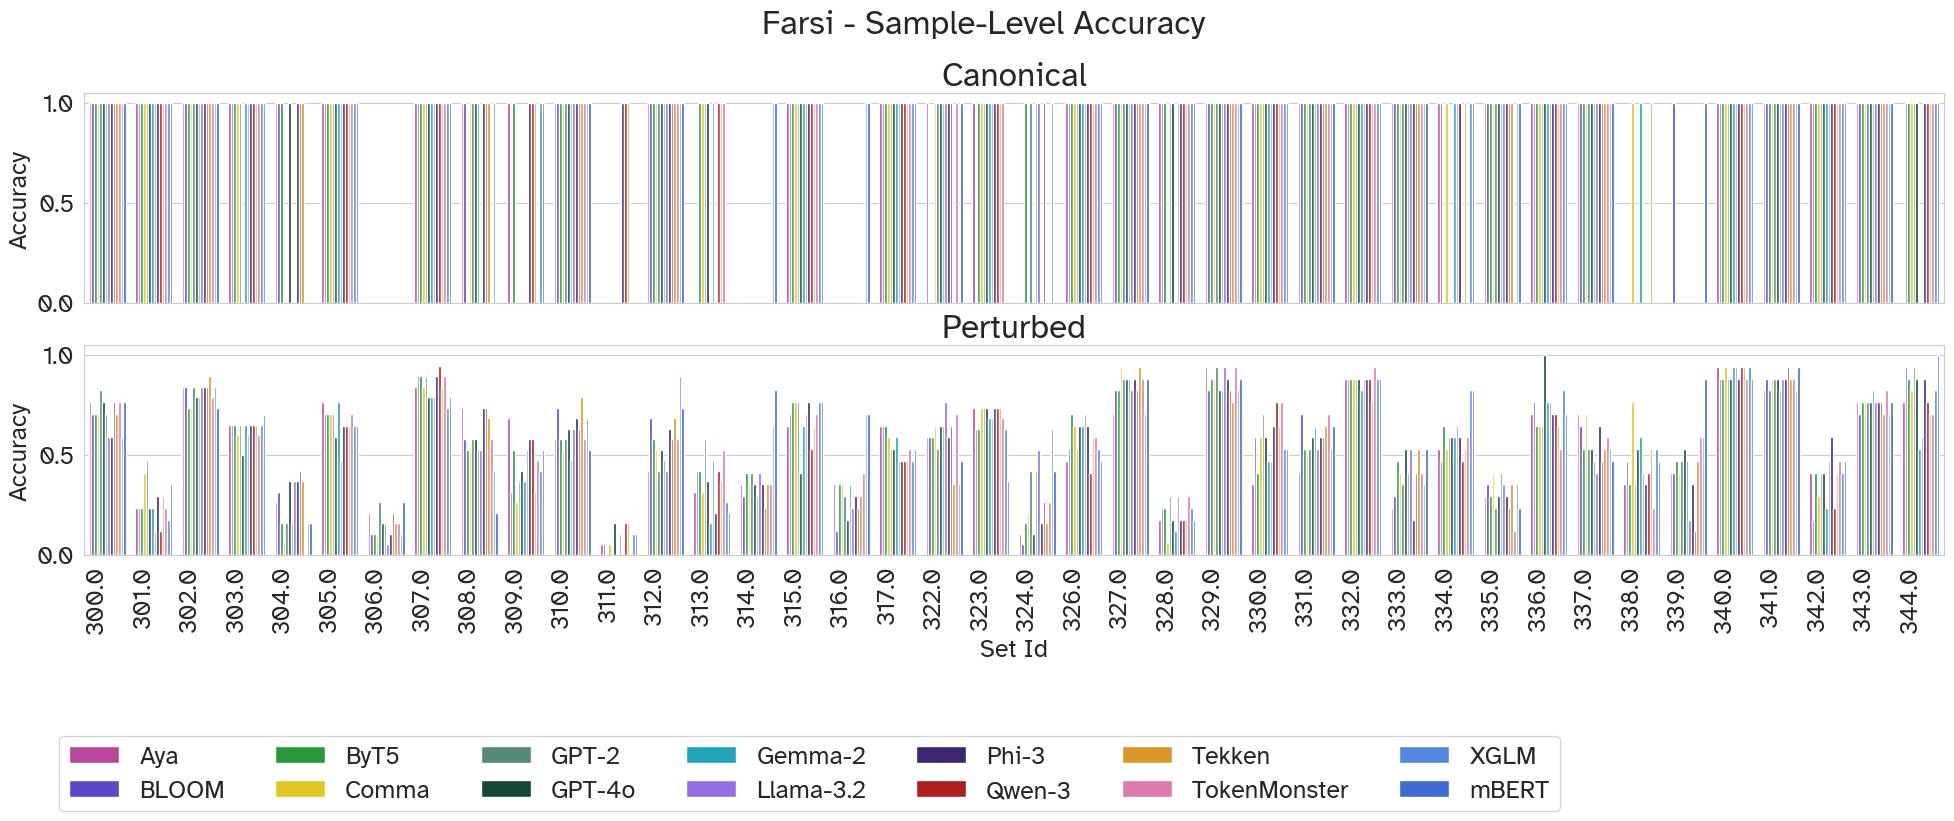

In [409]:
accuracies_by_model = all_samples.copy()
accuracies_by_model = all_samples.pivot_table(
    index=["set_id", "model_name", "is_canonical"], values=METRIC, aggfunc="mean"
).reset_index()
fig, axs = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
axs = axs.flat
sns.barplot(
    accuracies_by_model[accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[0],
    legend=False,
)
axs[0].set_title("Canonical")
axs[1].set_title("Perturbed")

sns.barplot(
    accuracies_by_model[~accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[1],
    legend=True,
)
axs[1].legend(bbox_to_anchor=(0.8, -0.8, 0, 0), ncol=7)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Set Id")
axs[0].set_ylabel(f"Accuracy")
axs[1].set_ylabel(f"Accuracy")
# Specify the questions
fig.suptitle(f"{title_pattern}Sample-Level Accuracy", y=1.02)
plt.savefig(OUTPUT_DIR/f"by_samples_canonical_vs_perturbed.png", pad_inches=0, bbox_inches="tight")

plt.show()

In [410]:
samples

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id
10245,0,2,"[[[-9.4375, False]], [[-9.375, False]], [[-6.0...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_canonical,دکتر احمدی یک جراح است. شغل دکتر احمدی,...,46,15,40,14,16,69,Canonical,Large,True,0.0
9791,0,1,"[[[-16.75, False]], [[-13.6875, False]], [[-16...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_colloquial,دکتر احمدی جراحه. دکتر احمدی,...,32,11,29,11,12,51,Colloquial,Large,False,1.0
9832,1,1,"[[[-15.75, False]], [[-13.875, False]], [[-15....","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_dialects,دکتر اَمَدی یه جرا هست. شغل آقای اَمَدی,...,46,18,40,19,19,72,Dialects,Large,False,1.0
10418,0,0,"[[[-30.375, False]], [[-25.5, False]], [[-22.2...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_optional...,دُکتُر اَحمَدي یِک جرّاحْ است.شُغلِ دُکْتُر ا...,...,66,33,52,34,36,95,Optional diacritics,Large,False,2.0
10285,0,0,"[[[-16.875, False]], [[-19.75, False]], [[-14....","[acc, acc_norm]",0,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_romaniza...,Dr Ahmadi yek jarrah ast. Shoghle Dr Ahmadi,...,17,17,18,15,16,23,Romanization,Large,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7839,355,2,"[[[-19.375, False]], [[-18.125, False]], [[-13...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد شخص از جمله «تره لطفاً یه پرواز به پاریس ر...,...,66,25,56,25,23,96,Dialects,Medium,False,13.0
7840,356,0,"[[[-12.5, False]], [[-19.875, False]], [[-17.7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد شخص از جمله «می‌توانید لطفاً یک پرواز به پ...,...,78,25,63,24,22,111,Dialects,Medium,False,14.0
7841,357,2,"[[[-39.0, False]], [[-34.25, False]], [[-24.87...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد جمله‌ی « مِتِنِه یَک پرواز به پاریس رزرو ک...,...,60,26,53,28,28,93,Dialects,Medium,False,15.0
7842,358,1,"[[[-57.5, False]], [[-43.5, False]], [[-48.0, ...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد شخص از جمله «بِتاندی لطفاً اِتا پرواز به پ...,...,76,32,65,31,29,114,Dialects,Medium,False,16.0


In [411]:
samples

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id
10245,0,2,"[[[-9.4375, False]], [[-9.375, False]], [[-6.0...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_canonical,دکتر احمدی یک جراح است. شغل دکتر احمدی,...,46,15,40,14,16,69,Canonical,Large,True,0.0
9791,0,1,"[[[-16.75, False]], [[-13.6875, False]], [[-16...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_colloquial,دکتر احمدی جراحه. دکتر احمدی,...,32,11,29,11,12,51,Colloquial,Large,False,1.0
9832,1,1,"[[[-15.75, False]], [[-13.875, False]], [[-15....","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_dialects,دکتر اَمَدی یه جرا هست. شغل آقای اَمَدی,...,46,18,40,19,19,72,Dialects,Large,False,1.0
10418,0,0,"[[[-30.375, False]], [[-25.5, False]], [[-22.2...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_optional...,دُکتُر اَحمَدي یِک جرّاحْ است.شُغلِ دُکْتُر ا...,...,66,33,52,34,36,95,Optional diacritics,Large,False,2.0
10285,0,0,"[[[-16.875, False]], [[-19.75, False]], [[-14....","[acc, acc_norm]",0,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_farsi_romaniza...,Dr Ahmadi yek jarrah ast. Shoghle Dr Ahmadi,...,17,17,18,15,16,23,Romanization,Large,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7839,355,2,"[[[-19.375, False]], [[-18.125, False]], [[-13...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد شخص از جمله «تره لطفاً یه پرواز به پاریس ر...,...,66,25,56,25,23,96,Dialects,Medium,False,13.0
7840,356,0,"[[[-12.5, False]], [[-19.875, False]], [[-17.7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد شخص از جمله «می‌توانید لطفاً یک پرواز به پ...,...,78,25,63,24,22,111,Dialects,Medium,False,14.0
7841,357,2,"[[[-39.0, False]], [[-34.25, False]], [[-24.87...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد جمله‌ی « مِتِنِه یَک پرواز به پاریس رزرو ک...,...,60,26,53,28,28,93,Dialects,Medium,False,15.0
7842,358,1,"[[[-57.5, False]], [[-43.5, False]], [[-48.0, ...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_dialects,قصد شخص از جمله «بِتاندی لطفاً اِتا پرواز به پ...,...,76,32,65,31,29,114,Dialects,Medium,False,16.0


                                                           acc_norm
model_name task_pretty_name                                        
Aya        Arabic Keyboard for Farsi                       0.350000
           Canonical                                       0.775000
           Code/language/script switching                  0.750000
           Colloquial                                      0.675000
           Dialects                                        0.541667
...                                                             ...
mBERT      Number Romanization                             0.461538
           Optional diacritics                             0.550000
           Romanization                                    0.450000
           Spelled out                                     0.357143
           Word Spacing/Zero-width characters/Extra Space  0.725000

[168 rows x 1 columns]


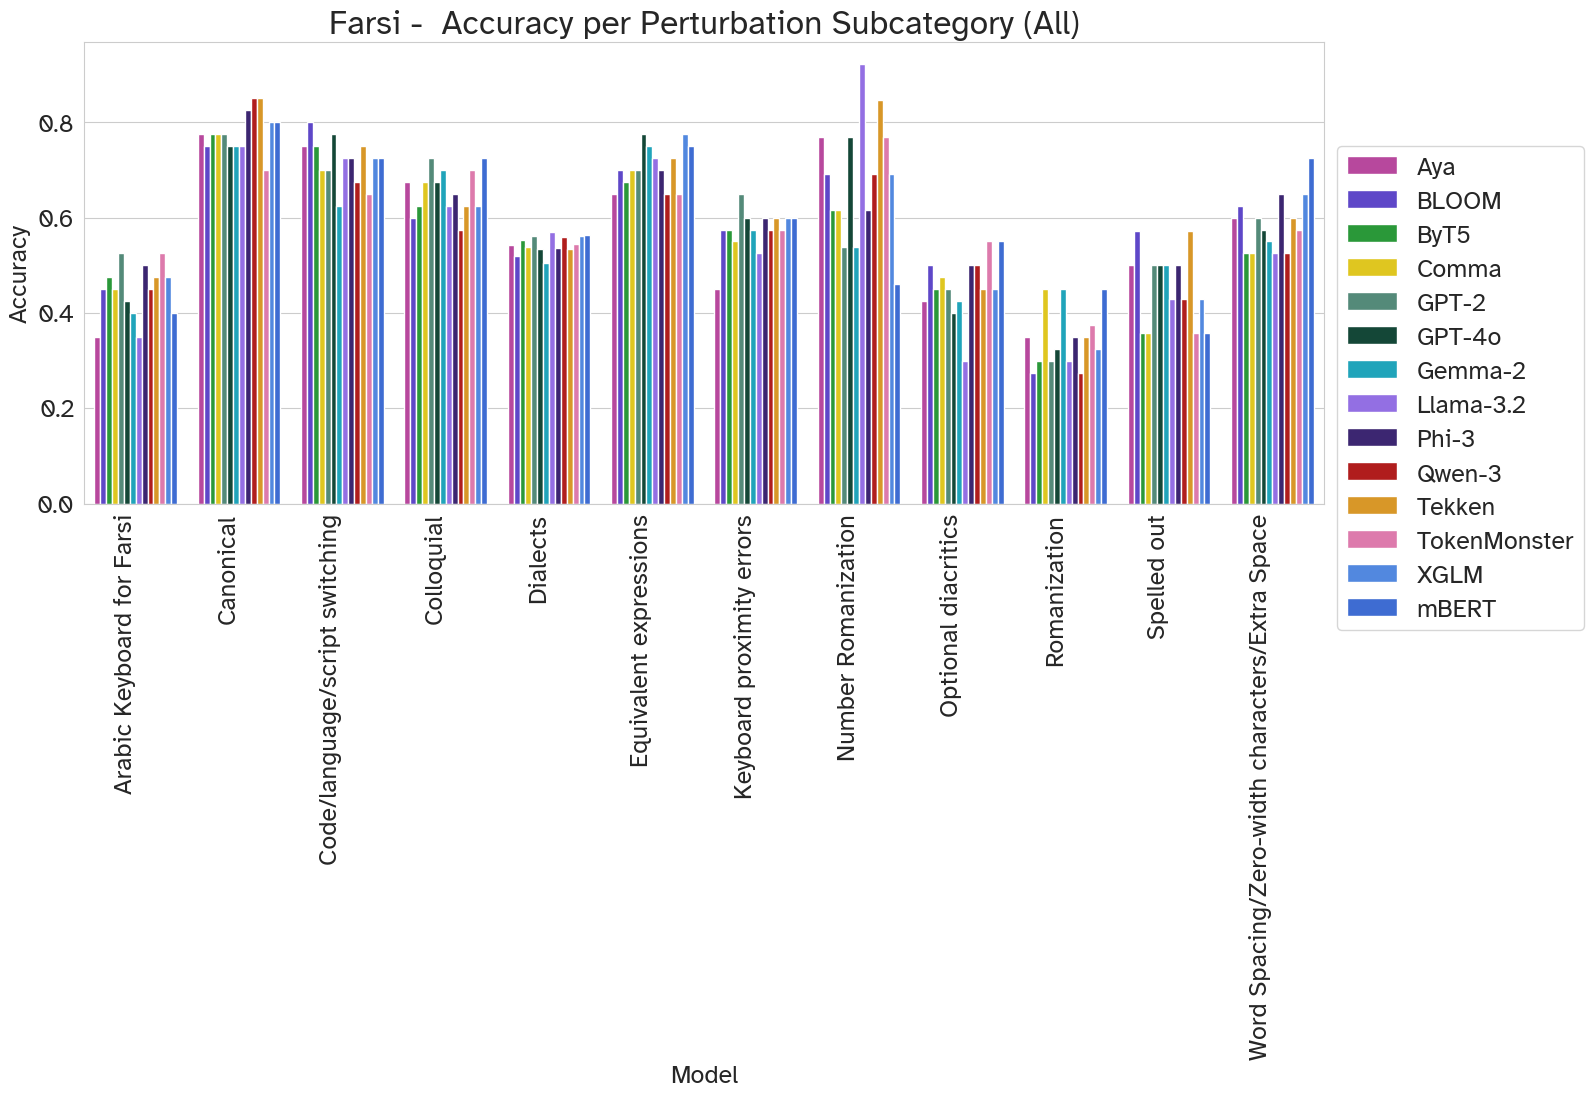

In [412]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = samples.pivot_table(
    index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="mean"
)
fig, axs = plt.subplots(1, 1, figsize=(16, 6))
sns.barplot(
    accuracies_by_model,
    x="task_pretty_name",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy")
plt.title(f"{title_pattern} Accuracy per Perturbation Subcategory {suffix}")
plt.legend(bbox_to_anchor=(1, 0.8))
plt.savefig(OUTPUT_DIR/f"combined_{METRIC}.png", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [413]:
samples.keys()

Index(['doc_id', 'target', 'resps', 'metrics', 'acc', 'acc_norm', 'model_name',
       'tokenizer_name', 'task', 'question', 'choices', 'answer',
       'answer_label', 'split', 'subcategories', 'category', 'lang',
       'second_lang', 'notes', 'id', 'set_id', 'variation_id',
       'vanilla_cos_sim_to_canonical.CohereLabs/aya-expanse-8b',
       'vanilla_cos_sim_to_canonical.Qwen/Qwen3-8B',
       'vanilla_cos_sim_to_canonical.bigscience/bloom',
       'vanilla_cos_sim_to_canonical.common-pile/comma-v0.1-1t',
       'vanilla_cos_sim_to_canonical.facebook/xglm-564M',
       'vanilla_cos_sim_to_canonical.google-bert/bert-base-multilingual-cased',
       'vanilla_cos_sim_to_canonical.google/byt5-small',
       'vanilla_cos_sim_to_canonical.google/gemma-2-2b',
       'vanilla_cos_sim_to_canonical.gpt2',
       'vanilla_cos_sim_to_canonical.meta-llama/Llama-3.2-1B',
       'vanilla_cos_sim_to_canonical.microsoft/Phi-3-mini-4k-instruct',
       'vanilla_cos_sim_to_canonical.mistralai/tekke

In [414]:
samples.sort_values(["category"])["category"].unique()

array(['', '#REF!', 'Mathematical & Scientific Notation', 'Noise',
       'Script / Orthography', 'Social Media & Informal Text'],
      dtype=object)

Total tasks: 12
Plotting Arabic Keyboard for Farsi into position 1
Task 1/12: Arabic Keyboard for Farsi
  Position: 1, Plots in figure: 1
  Last task: False, Figure full: False
Plotting Canonical into position 2
Task 2/12: Canonical
  Position: 2, Plots in figure: 2
  Last task: False, Figure full: False
Plotting Code/language/script switching into position 3
Task 3/12: Code/language/script switching
  Position: 3, Plots in figure: 3
  Last task: False, Figure full: False
Plotting Colloquial into position 4
Task 4/12: Colloquial
  Position: 4, Plots in figure: 4
  Last task: False, Figure full: False
Plotting Dialects into position 5
Task 5/12: Dialects
  Position: 5, Plots in figure: 5
  Last task: False, Figure full: False
Plotting Equivalent expressions into position 6
Task 6/12: Equivalent expressions
  Position: 6, Plots in figure: 6
  Last task: False, Figure full: False
Plotting Keyboard proximity errors into position 7
Task 7/12: Keyboard proximity errors
  Position: 7, Plots i

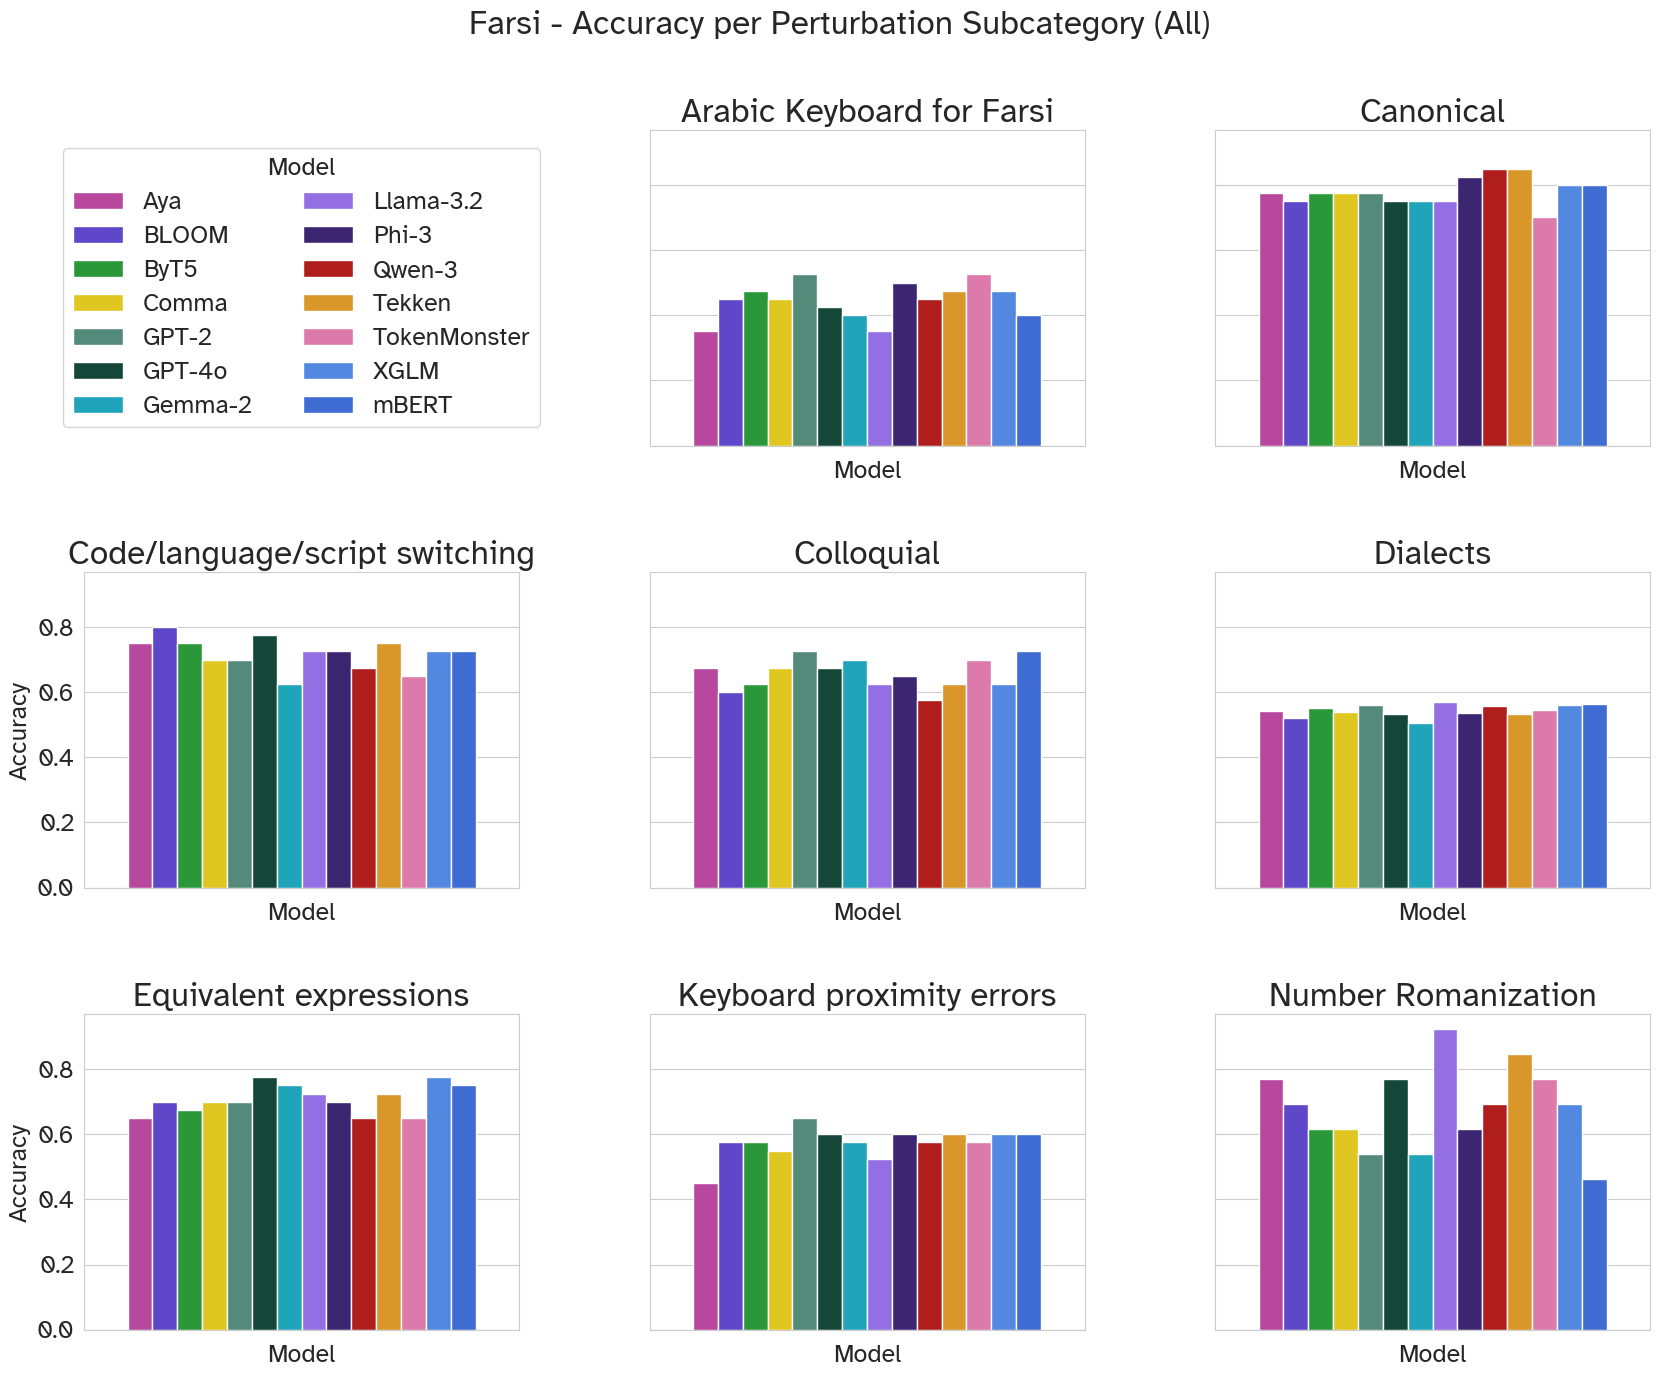

  Created new figure 1
Plotting Optional diacritics into position 1
Task 9/12: Optional diacritics
  Position: 1, Plots in figure: 1
  Last task: False, Figure full: False
Plotting Romanization into position 2
Task 10/12: Romanization
  Position: 2, Plots in figure: 2
  Last task: False, Figure full: False
Plotting Spelled out into position 3
Task 11/12: Spelled out
  Position: 3, Plots in figure: 3
  Last task: False, Figure full: False
Plotting Word Spacing/Zero-width characters/Extra Space into position 4
Task 12/12: Word Spacing/Zero-width characters/Extra Space
  Position: 4, Plots in figure: 4
  Last task: True, Figure full: False
  Saved: by_task_acc_norm_1.png


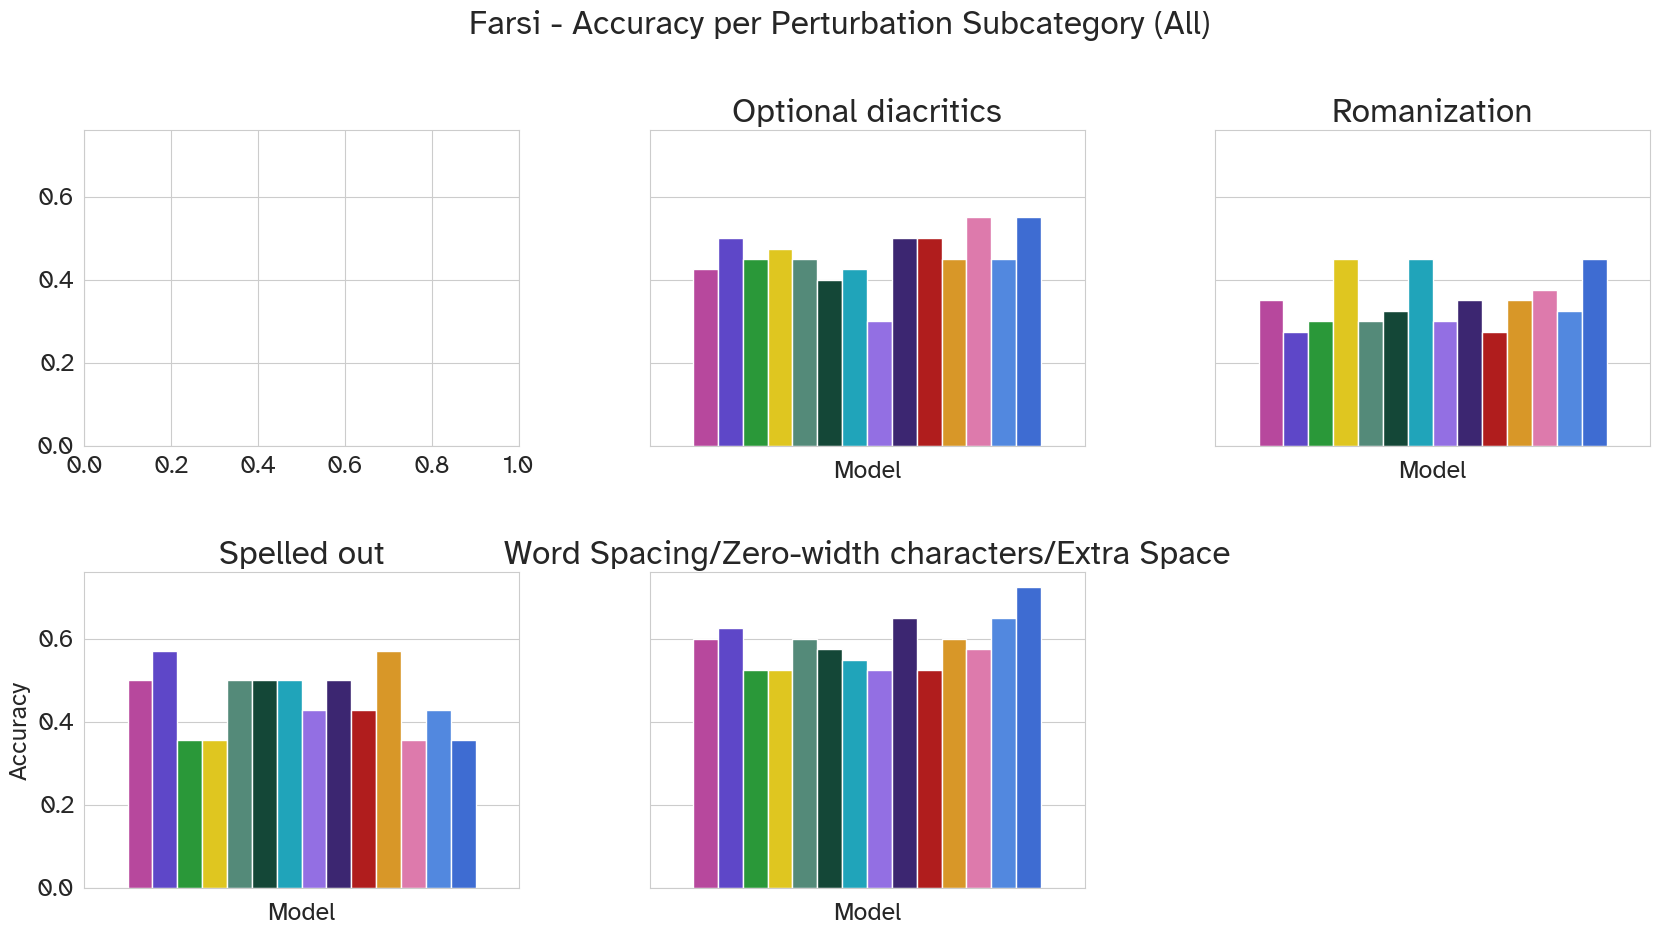


Total figures saved: 2
Tasks processed: 12
                                                           acc_norm
model_name task_pretty_name                                        
Aya        Arabic Keyboard for Farsi                       0.350000
           Canonical                                       0.775000
           Code/language/script switching                  0.750000
           Colloquial                                      0.675000
           Dialects                                        0.541667
...                                                             ...
mBERT      Number Romanization                             0.461538
           Optional diacritics                             0.550000
           Romanization                                    0.450000
           Spelled out                                     0.357143
           Word Spacing/Zero-width characters/Extra Space  0.725000

[168 rows x 1 columns]


In [415]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Accuracy per Perturbation Subcategory {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None
samples = samples.sort_values(["model_name", "subcategories", "set_id", "variation_id"])
samples = samples.sort_values(["model_name", "subcategories"])
tasks = samples["task_pretty_name"].unique()

# Flatten the axes array for easier indexing
axs_flat = axs.flatten()
total_plots_per_figure = nrows * ncols

print(f"Total tasks: {len(tasks)}")

for i, task in enumerate(tasks):  # Start from 0
    # Calculate position (skip position 0 for legend)
    plot_position = (i % (total_plots_per_figure - 1)) + 1
    
    print(f"Plotting {task} into position {plot_position}")
    filter_ = samples["task_pretty_name"] == task
    tmp = samples[filter_]
    ax = axs_flat[plot_position]
    
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC, ax=ax, legend=(i == 0), 
        palette=palette, errorbar=None, width=0.8
    )
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.set_title(task)
    
    # Add legend to position 0 of the first figure
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        axs_flat[0].clear()
        axs_flat[0].axis("off")
        axs_flat[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        ax.legend().set_visible(False)
    
    # Check if we need to save the current figure
    is_last_task = i == len(tasks) - 1
    plots_in_current_figure = (i % (total_plots_per_figure - 1)) + 1  # +1 because we start from 1
    is_figure_full = plots_in_current_figure == (total_plots_per_figure - 1)  # -1 for legend
    
    print(f"Task {i+1}/{len(tasks)}: {task}")
    print(f"  Position: {plot_position}, Plots in figure: {plots_in_current_figure}")
    print(f"  Last task: {is_last_task}, Figure full: {is_figure_full}")
    
    # Save figure when it's full OR when it's the last task
    if is_figure_full or is_last_task:
        # Hide unused subplots in current figure
        if is_last_task and not is_figure_full:
            # Hide remaining subplots
            for j in range(plots_in_current_figure + 1, total_plots_per_figure):
                axs_flat[j].set_visible(False)
        
        # Apply consistent spacing
        plt.subplots_adjust(
            left=0.08, right=0.95, top=0.9, bottom=0.1,
            wspace=0.3, hspace=0.4
        )
        
        # Save the figure
        filename = f"by_task_{METRIC}_{fig_cnt}.png"
        plt.savefig(OUTPUT_DIR / filename, pad_inches=0.1, bbox_inches="tight")
        print(f"  Saved: {filename}")
        plt.show()
        
        fig_cnt += 1
        
        # Create new figure if not the last task
        if not is_last_task:
            fig, axs = get_new_fig(
                nrows=nrows, ncols=ncols, 
                title=f"{title_pattern}Accuracy per Perturbation Subcategory {suffix}"
            )
            axs_flat = axs.flatten()
            print(f"  Created new figure {fig_cnt}")

print(f"\nTotal figures saved: {fig_cnt}")
print(f"Tasks processed: {len(tasks)}")
print(accuracies_by_model)

In [416]:
samples[samples["task_pretty_name"] == "Contractions"]["question"]

Series([], Name: question, dtype: object)

In [417]:
# print(samples.pivot_table(index=["category", "task_pretty_name", "model_name"], values=METRIC, aggfunc="count")["Qwen"].to_markdown())
pv = samples.pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
# ["mBERT"]
pv = pv.loc["Aya"]
pv

print(pv.to_markdown())


| task_pretty_name                               |   acc_norm |
|:-----------------------------------------------|-----------:|
| Arabic Keyboard for Farsi                      |         40 |
| Canonical                                      |         40 |
| Code/language/script switching                 |         40 |
| Colloquial                                     |         40 |
| Dialects                                       |        360 |
| Equivalent expressions                         |         40 |
| Keyboard proximity errors                      |         40 |
| Number Romanization                            |         13 |
| Optional diacritics                            |         40 |
| Romanization                                   |         40 |
| Spelled out                                    |         14 |
| Word Spacing/Zero-width characters/Extra Space |         40 |


## By Category

Plotting  into position 1
1 False False
Plotting Social Media & Informal Text into position 2
2 False False
Plotting Script / Orthography into position 3
3 False False
Plotting Noise into position 4
4 False False
Plotting #REF! into position 5
5 False False
Plotting Mathematical & Scientific Notation into position 6
6 False False


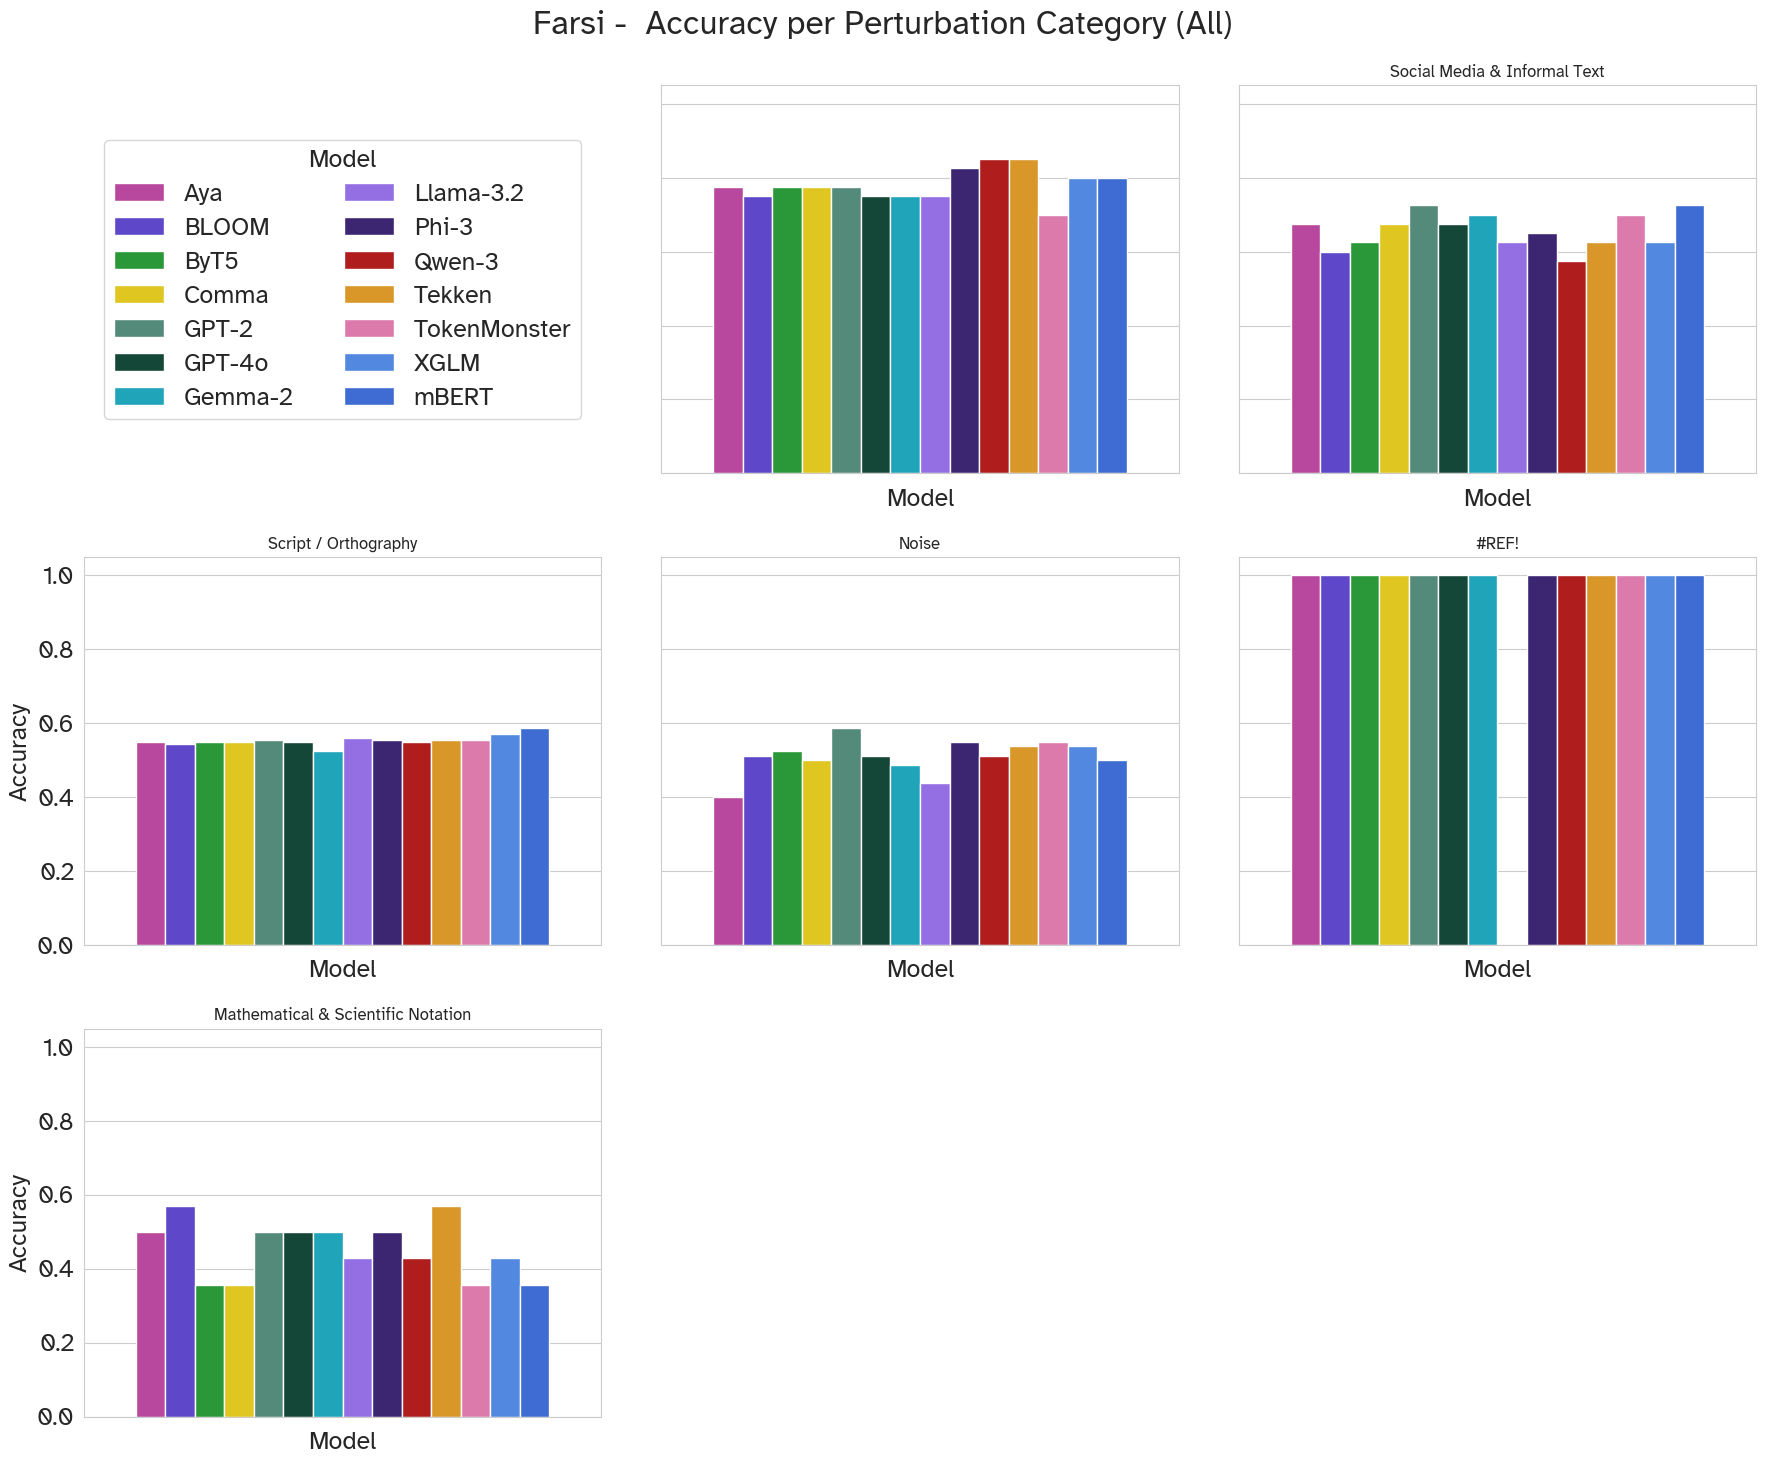

                                                           acc_norm
model_name task_pretty_name                                        
Aya        Arabic Keyboard for Farsi                       0.350000
           Canonical                                       0.775000
           Code/language/script switching                  0.750000
           Colloquial                                      0.675000
           Dialects                                        0.541667
...                                                             ...
mBERT      Number Romanization                             0.461538
           Optional diacritics                             0.550000
           Romanization                                    0.450000
           Spelled out                                     0.357143
           Word Spacing/Zero-width characters/Extra Space  0.725000

[168 rows x 1 columns]


In [418]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy per Perturbation Category {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
# PLOT_AXIS = "vocab_bucket"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None
## category might have multiple entries
FILTER_AXIS = "category"

samples = samples.sort_values(["model_name", "set_id", "variation_id"])
tasks = samples[FILTER_AXIS].unique()
for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples[FILTER_AXIS] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC,ax=ax, legend=i == 1, palette=palette, errorbar=None
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy")
    title = task
    ax.set_title(title, fontsize=12)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.png", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy per Perturbation Category {suffix}")
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_by_{PLOT_AXIS.lower()}_{METRIC}_{fig_cnt}.png", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

## Canonical Eng vs Other Langs

In [419]:
samples['acc_norm']

10245    1
9791     1
9832     1
9833     1
9834     1
        ..
8056     1
7883     1
7923     1
8216     1
7835     1
Name: acc_norm, Length: 10458, dtype: int64

In [420]:
samples["is_canonical"] & (samples["set_id"].isin(list(range(300,345)) + [str(i) for i in range(300, 345)]))

10245    False
9791     False
9832     False
9833     False
9834     False
         ...  
8056     False
7883     False
7923     False
8216     False
7835     False
Length: 10458, dtype: bool

In [421]:
samples["set_id"].isin(list(range(300,345)))

10245    False
9791     False
9832     False
9833     False
9834     False
         ...  
8056     False
7883     False
7923     False
8216     False
7835     False
Name: set_id, Length: 10458, dtype: bool

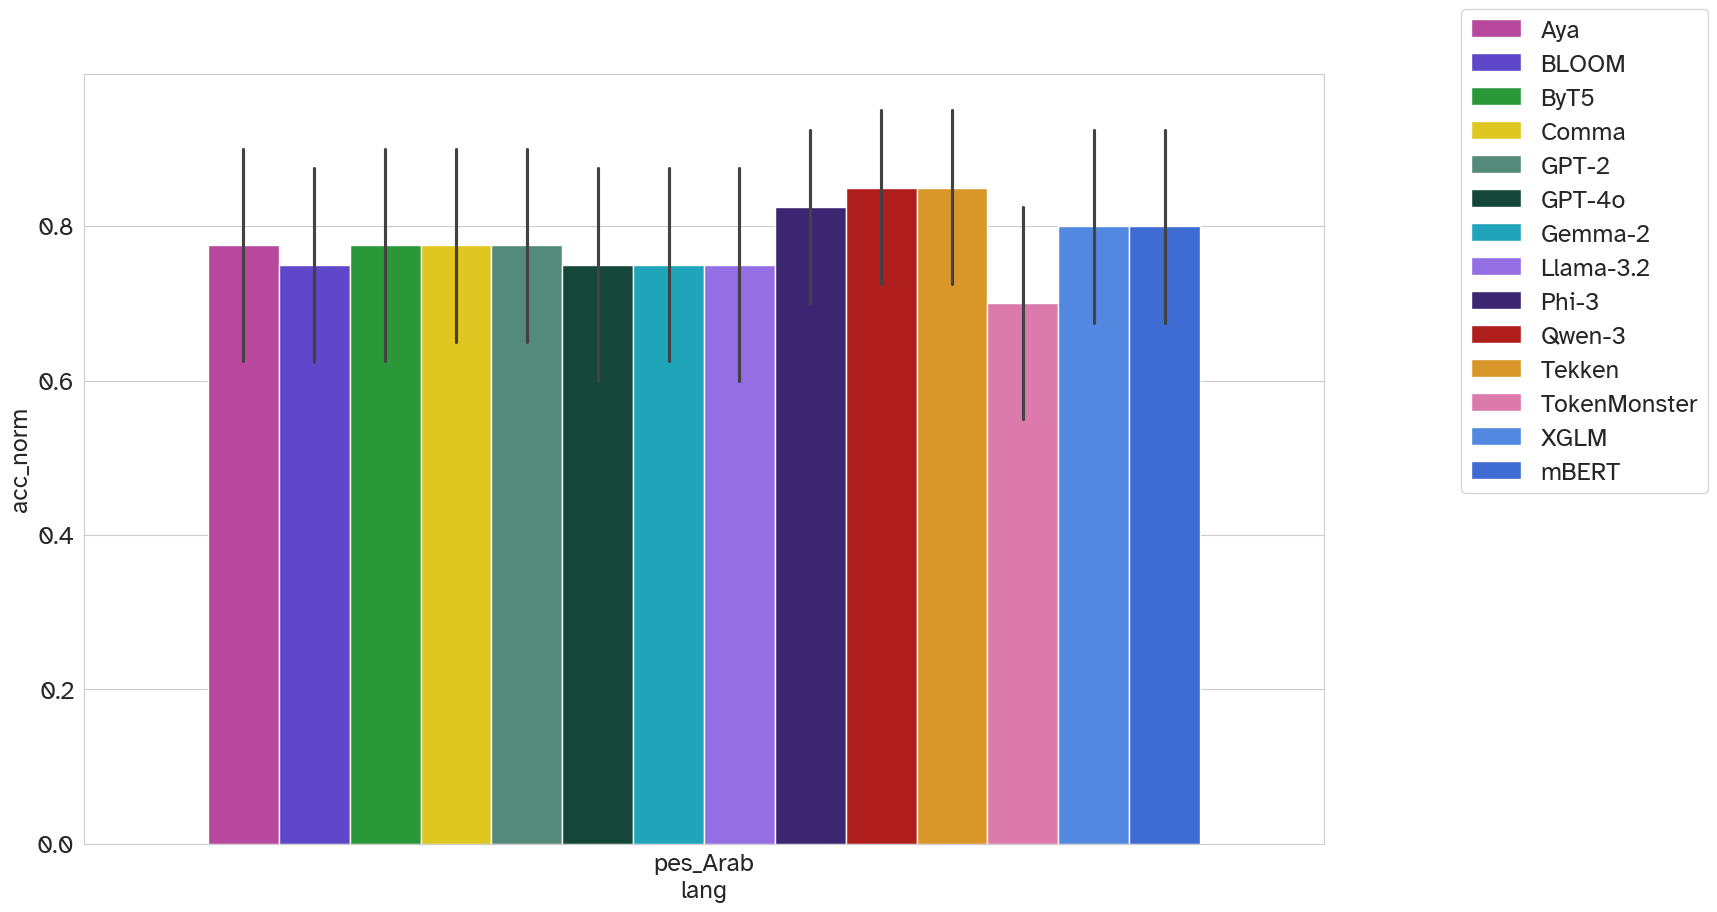

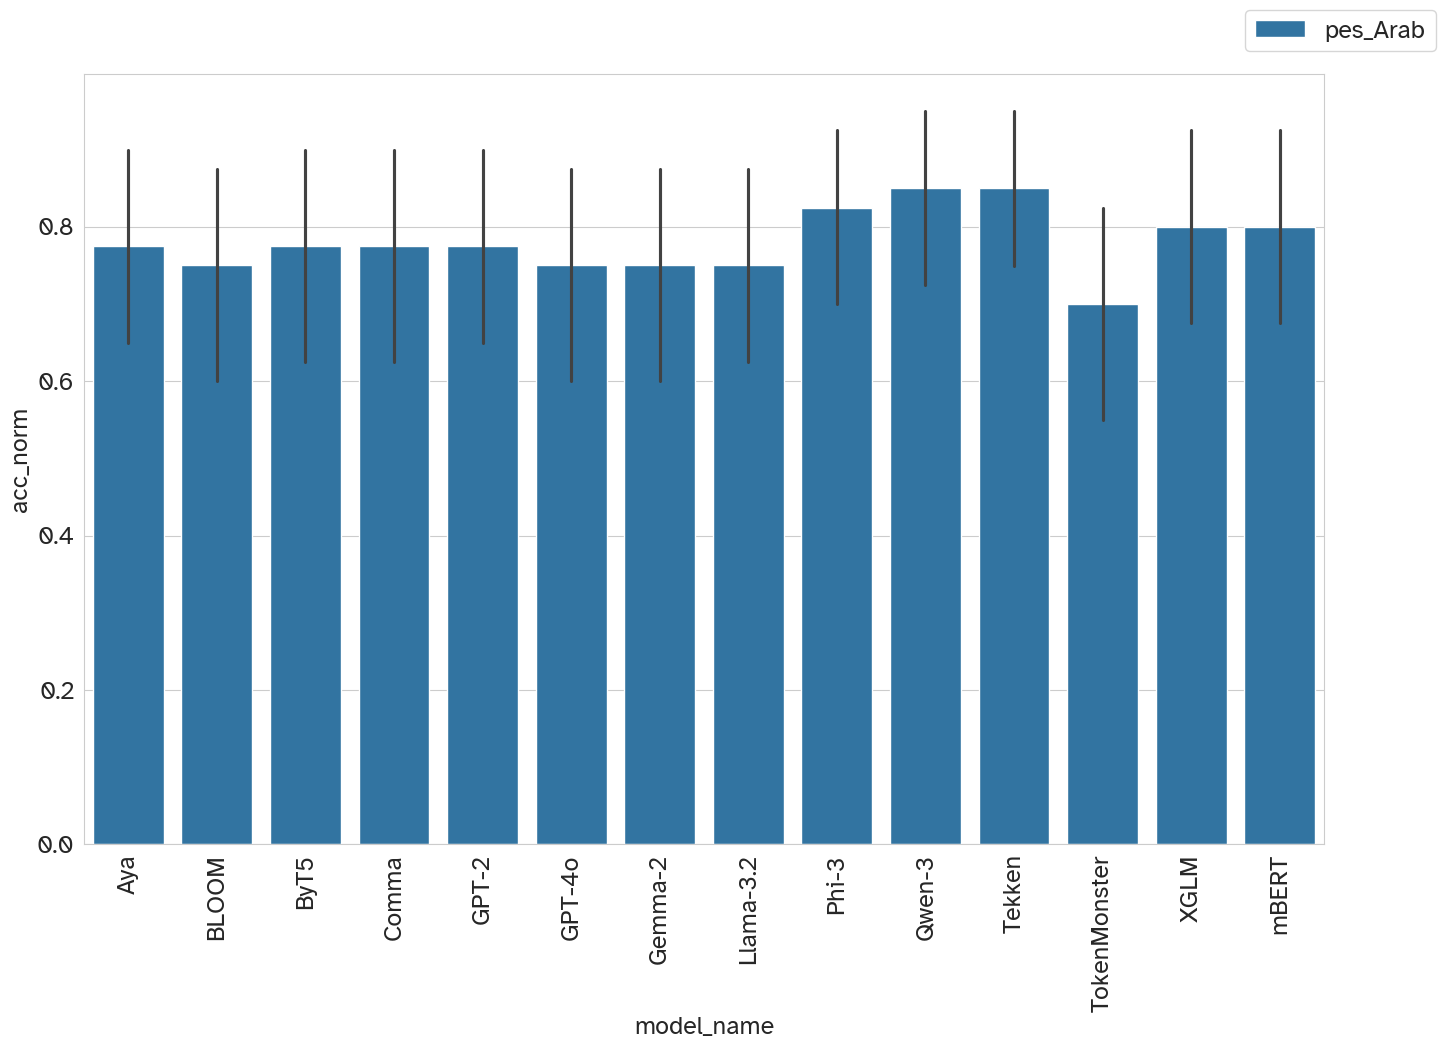

| lang     |   acc_norm |
|:---------|-----------:|
| pes_Arab |   0.780357 |


In [422]:
filter_ = samples["is_canonical"] & (samples["set_id"].isin(list(range(300,345)) + [str(i) for i in range(300, 345)] + [str(float(i)) for i in range(300, 345)]))

fig = plt.figure(figsize=(16, 10))
sns.barplot(samples[filter_], x="lang", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
plt.legend(bbox_to_anchor=(1.1,1.1))
plt.show()

fig = plt.figure(figsize=(16, 10))
sns.barplot(samples[filter_], x="model_name", y=METRIC, hue="lang")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.1,1.1))
plt.show()

print(samples[filter_].pivot_table(index=["lang"], values=METRIC, aggfunc="mean").sort_values(METRIC, ascending=False).to_markdown())

In [423]:
# samples["Lang"].unique()
samples[filter_ & (samples["model_name"] == "mBERT")]

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id
8137,0,2,"[[[-10.4375, False]], [[-10.8125, False]], [[-...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,دکتر احمدی یک جراح است. شغل دکتر احمدی,...,46,15,40,14,16,69,Canonical,Medium,True,0.0
8138,1,1,"[[[-8.625, False]], [[-6.0, False]], [[-8.625,...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,رنگ آسمان,...,10,4,10,5,5,19,Canonical,Medium,True,0.0
8139,2,0,"[[[-5.65625, False]], [[-9.25, False]], [[-11....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,این خانه ۲٫۸۵۰٫۰۰۰٫۰۰۰ تومان است. قیمت این خانه,...,63,17,61,23,20,89,Canonical,Medium,True,0.0
8140,3,2,"[[[-10.0, False]], [[-12.4375, False]], [[-8.1...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,امروز تاریخ ۱۴۰۳/۰۸/۱۵ است. امروز,...,45,15,42,18,15,61,Canonical,Medium,True,0.0
8141,4,2,"[[[-10.5, False]], [[-11.125, False]], [[-10.6...","[acc, acc_norm]",0,0,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,تعداد قاره های روی زمین,...,26,7,24,7,7,42,Canonical,Medium,True,0.0
8142,5,2,"[[[-11.6875, False]], [[-13.5, False]], [[-9.7...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,پایتخت ایران,...,16,4,13,4,4,23,Canonical,Medium,True,0.0
8143,6,2,"[[[-12.875, False]], [[-13.8125, False]], [[-1...","[acc, acc_norm]",0,0,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,هر هفته,...,9,3,9,3,3,14,Canonical,Medium,True,0.0
8144,7,1,"[[[-14.9375, False]], [[-12.4375, False]], [[-...","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,هر روز,...,7,2,7,2,2,11,Canonical,Medium,True,0.0
8145,8,0,"[[[-12.375, False]], [[-13.375, False]], [[-13...","[acc, acc_norm]",0,0,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,تعداد‌ پاهای یک گا‌و,...,26,10,21,9,9,39,Canonical,Medium,True,0.0
8146,9,2,"[[[-13.6875, False]], [[-15.5, False]], [[-13....","[acc, acc_norm]",1,1,mBERT,google-bert/bert-base-multilingual-cased,tokenizer_robustness_completion_farsi_canonical,تعداد دقیقه های دو ساعت,...,27,6,24,7,6,42,Canonical,Medium,True,0.0


### By Model

In [424]:
OUTPUT_DIR.absolute()

PosixPath('/Users/malikehehghaghi/Desktop/Tokenizers/notebooks/output/paper-results-v5/farsi/all')

Plotting Aya into position 1
Plotting BLOOM into position 2
Plotting ByT5 into position 3
Plotting Comma into position 4


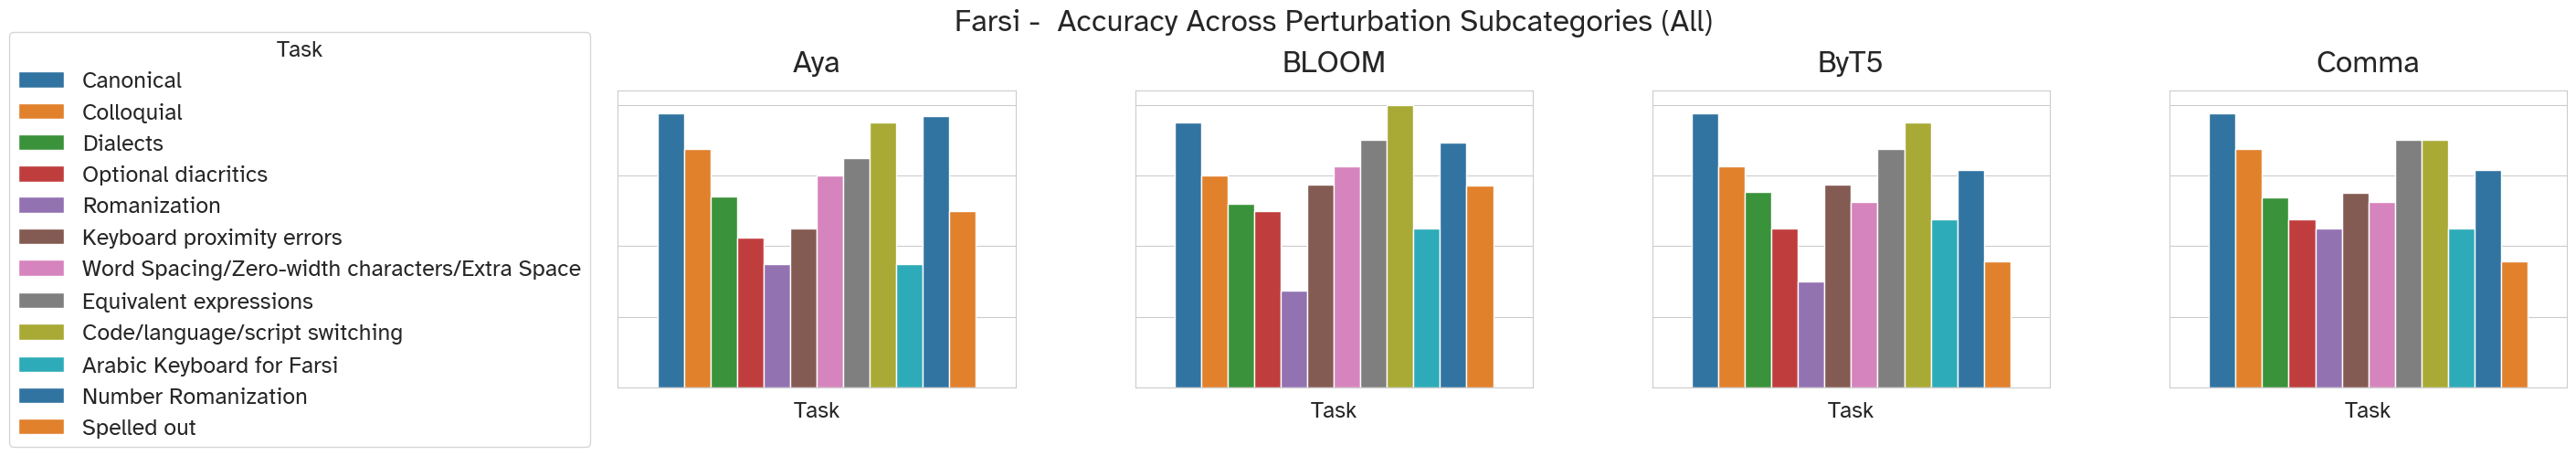

Plotting GPT-2 into position 0
Plotting GPT-4o into position 1
Plotting Gemma-2 into position 2
Plotting Llama-3.2 into position 3
Plotting Phi-3 into position 4


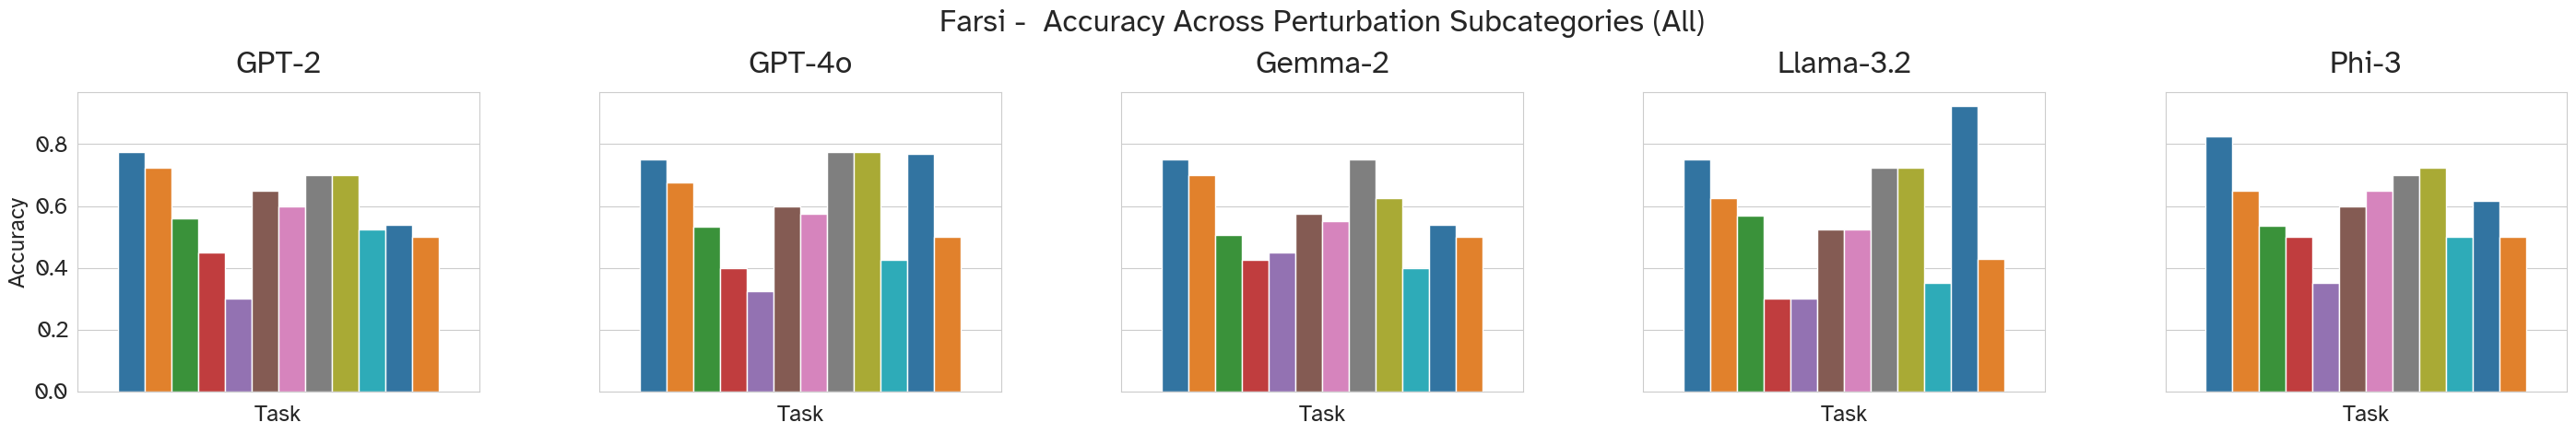

Plotting Qwen-3 into position 0
Plotting Tekken into position 1
Plotting TokenMonster into position 2
Plotting XGLM into position 3
Plotting mBERT into position 4


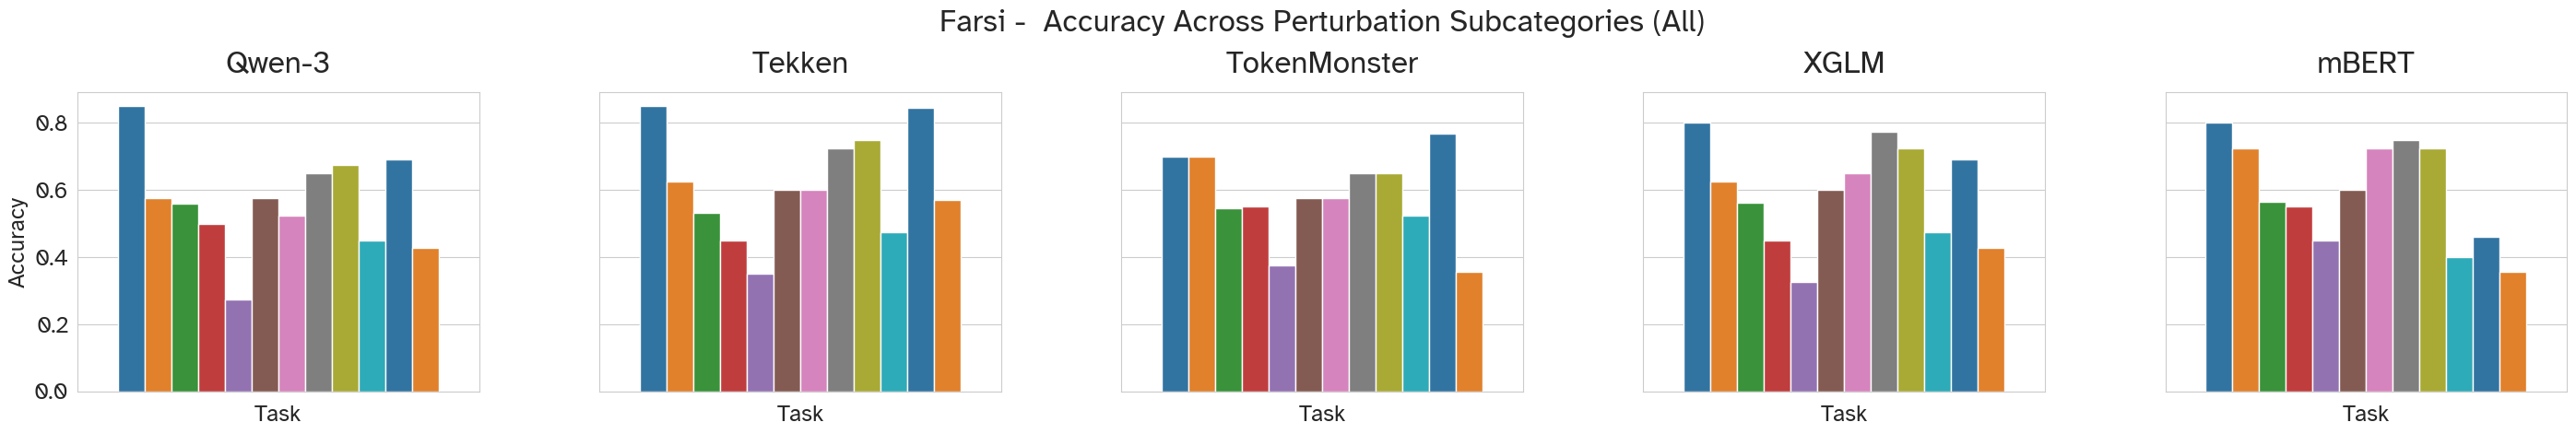

                                                           acc_norm
model_name task_pretty_name                                        
Aya        Arabic Keyboard for Farsi                       0.350000
           Canonical                                       0.775000
           Code/language/script switching                  0.750000
           Colloquial                                      0.675000
           Dialects                                        0.541667
...                                                             ...
mBERT      Number Romanization                             0.461538
           Optional diacritics                             0.550000
           Romanization                                    0.450000
           Spelled out                                     0.357143
           Word Spacing/Zero-width characters/Extra Space  0.725000

[168 rows x 1 columns]


In [425]:
nrows, ncols = 1, 5
PLOT_AXIS="model_name"
HUE="task_pretty_name"

fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy Across Perturbation Subcategories {suffix}"
)
fig_cnt = 0
models = samples[PLOT_AXIS].unique()
models = sorted(models)

for i, model in enumerate(models, 1):
    print(f"Plotting {model} into position {i % len(axs)}")
    filter_ = samples[PLOT_AXIS] == model
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=HUE, y=METRIC, palette="tab10", ax=ax, legend=i == 1, errorbar=None
    )
    ax.set_xlabel("Task")
    ax.set_ylabel(f"Accuracy")
    title=model
    ax.set_title(title, pad=15)  # Reduced padding
    
    is_last_task = i == len(models)
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    
    if i == 1:
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Task", loc="center", ncol=1)
        axs[1].legend().set_visible(False)
    
    if is_last_task or is_end_of_6:
        if is_last_task:
            num_plots_in_current_fig = (i % (ncols * nrows)) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
        
        # Manual spacing instead of tight_layout
        plt.subplots_adjust(
            left=0.05,    # Left margin
            right=0.95,   # Right margin  
            top=0.8,      # Top margin (leave space for main title)
            bottom=0.15,  # Bottom margin
            wspace=0.3,   # Width spacing between subplots
            hspace=0.4    # Height spacing between subplots
        )
        
        plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.png", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig_cnt += 1
        
        if not is_last_task:
            fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=f"{title_pattern} Accuracy Across Perturbation Subcategories {suffix}")

# Final figure handling
if not (is_last_task or is_end_of_6):
    num_models = len(models)
    if num_models < ncols:
        for j in range((num_models % ncols) + 1, ncols):
            axs[j].set_visible(False)
    
    plt.subplots_adjust(
        left=0.05, right=0.95, top=0.8, bottom=0.15, 
        wspace=0.3, hspace=0.4
    )
    plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.png", pad_inches=0, bbox_inches="tight")
    plt.show()

print(accuracies_by_model)

### Examples per perturbation

In [426]:
pv = all_samples[all_samples["model_name"] == "Aya"].pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
pv.to_csv(OUTPUT_DIR/"sample_counts.csv")
pv


acc_norm
model_name task_pretty_name                                        
Aya        Arabic Keyboard for Farsi                             40
           Canonical                                             40
           Code/language/script switching                        40
           Colloquial                                            40
           Dialects                                             360
           Equivalent expressions                                40
           Keyboard proximity errors                             40
           Number Romanization                                   13
           Optional diacritics                                   40
           Romanization                                          40
           Spelled out                                           14
           Word Spacing/Zero-width characters/Extra Space        40

### Against tokenizer props

#### Token count

In [792]:
samples["token_counts"]

KeyError: 'token_counts'

In [793]:
models = samples["model_name"].unique()

sns.histplot(samples, x="model_name", y="token_counts")

ValueError: Could not interpret value `token_counts` for `y`. An entry with this name does not appear in `data`.

In [1]:
samples.columns

NameError: name 'samples' is not defined

In [766]:
toks = samples["tokenizer_name"].unique()
tok_count_cols = [f"token_counts.{tok_name}" for tok_name in toks]
tok_counts = samples[tok_count_cols]
tok_counts.columns=toks
tok_counts 


,CohereLabs/aya-expanse-8b,bigscience/bloom,google/byt5-small,common-pile/comma-v0.1-1t,gpt2,tiktoken/gpt-4o,google/gemma-2-2b,meta-llama/Llama-3.2-1B,microsoft/Phi-3-mini-4k-instruct,Qwen/Qwen3-8B,mistralai/tekken,tokenmonster/englishcode-32000-consistent-v1,facebook/xglm-564M,google-bert/bert-base-multilingual-cased
0,11,11,58,13,11,11,11,11,11,11,11,9,12,12
1,11,11,58,13,11,11,11,11,11,11,11,9,12,12
2,9,10,59,11,9,9,9,9,12,9,10,9,10,12
3,9,10,59,11,9,9,9,9,12,9,10,9,10,12
4,11,11,76,11,11,11,11,11,11,11,11,10,11,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56477,7,8,41,8,7,8,7,8,8,8,7,6,8,8
56478,7,8,41,8,7,8,7,8,8,8,7,6,8,8
56479,7,8,41,8,7,8,7,8,8,8,7,6,8,8
56480,7,8,41,8,7,8,7,8,8,8,7,6,8,8


In [767]:
samples["tokenizer_name"]

0                       CohereLabs/aya-expanse-8b
1                       CohereLabs/aya-expanse-8b
2                       CohereLabs/aya-expanse-8b
3                       CohereLabs/aya-expanse-8b
4                       CohereLabs/aya-expanse-8b
                           ...                   
56477    google-bert/bert-base-multilingual-cased
56478    google-bert/bert-base-multilingual-cased
56479    google-bert/bert-base-multilingual-cased
56480    google-bert/bert-base-multilingual-cased
56481    google-bert/bert-base-multilingual-cased
Name: tokenizer_name, Length: 56482, dtype: object

In [768]:
for i, row in samples.iterrows():
    samples.iloc[i, "token_count"]=

SyntaxError: invalid syntax (2112519002.py, line 2)